## 2.1 GNN 分子性质预测示例
本 Notebook 基于 **PyTorch Geometric (PyG)**，演示基于图神经网络的分子性质预测：
- **分类**：BBBP（MoleculeNet）
- **回归**：ESOL（MoleculeNet）

### （1） 导入必要的包

In [1]:
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool
from torch.utils.data import random_split
import torch_geometric.transforms as T
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from rdkit import Chem
import copy
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import SVG, display
from torch_geometric.utils.smiles import from_smiles
from rdkit.Chem.Draw import rdMolDraw2D
import os
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader



def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed_everything(42)
device = get_device()

### （2）数据集载入：BBBP（分类） & ESOL（回归）

In [2]:
# =========================================================
# 0. 加载 BBBP 和 ESOL 数据集
# =========================================================
def load_bbbp(root="./data"):
    """
    加载 BBBP 数据集。
    BBBP 是一个二分类数据集，任务通常是预测分子是否具有血脑屏障渗透性。
    
    参数
    ----
    root : str
        数据集保存路径。
    
    返回
    ----
    ds : MoleculeNet
        加载后的 BBBP 数据集对象。
    name : str
        数据集名称字符串。
    """
    ds = MoleculeNet(root=root, name="BBBP")
    return ds, "BBBP"


def load_esol(root="./data"):
    """
    加载 ESOL 数据集。
    ESOL 是一个回归数据集，任务通常是预测分子的水溶解度。
    
    参数
    ----
    root : str
        数据集保存路径。
    
    返回
    ----
    ds : MoleculeNet
        加载后的 ESOL 数据集对象。
    name : str
        数据集名称字符串。
    """
    ds = MoleculeNet(root=root, name="ESOL")
    return ds, "ESOL"


# =========================================================
# 1. 定义原子特征和化学键特征的“解码表”
#    说明：
#    PyG 中的 data.x 和 data.edge_attr 存储的是“索引值”，
#    不是直接可读的化学字符串。
#    因此我们需要借助映射表把它们翻译成人能读懂的含义。
# =========================================================
X_MAP = {
    # 原子序数：0~118
    "atomic_num": list(range(0, 119)),

    # 手性信息
    "chirality": [
        "CHI_UNSPECIFIED",
        "CHI_TETRAHEDRAL_CW",
        "CHI_TETRAHEDRAL_CCW",
        "CHI_OTHER",
        "CHI_TETRAHEDRAL",
        "CHI_ALLENE",
        "CHI_SQUAREPLANAR",
        "CHI_TRIGONALBIPYRAMIDAL",
        "CHI_OCTAHEDRAL",
    ],

    # 原子的度（连接到多少个原子）
    "degree": list(range(0, 11)),

    # 形式电荷
    "formal_charge": list(range(-5, 7)),

    # 氢原子数
    "num_hs": list(range(0, 9)),

    # 自由基电子数
    "num_radical_electrons": list(range(0, 5)),

    # 杂化类型
    "hybridization": [
        "UNSPECIFIED",
        "S",
        "SP",
        "SP2",
        "SP3",
        "SP3D",
        "SP3D2",
        "OTHER",
    ],

    # 是否芳香
    "is_aromatic": [False, True],

    # 是否在环中
    "is_in_ring": [False, True],
}


E_MAP = {
    # 键类型
    "bond_type": [
        "UNSPECIFIED",
        "SINGLE",
        "DOUBLE",
        "TRIPLE",
        "QUADRUPLE",
        "QUINTUPLE",
        "HEXTUPLE",
        "ONEANDAHALF",
        "TWOANDAHALF",
        "THREEANDAHALF",
        "FOURANDAHALF",
        "FIVEANDAHALF",
        "AROMATIC",
        "IONIC",
        "HYDROGEN",
        "THREECENTER",
        "DATIVEONE",
        "DATIVE",
        "DATIVEL",
        "DATIVER",
        "OTHER",
        "ZERO",
    ],

    # 键的立体化学信息
    "stereo": [
        "STEREONONE",
        "STEREOANY",
        "STEREOZ",
        "STEREOE",
        "STEREOCIS",
        "STEREOTRANS",
    ],

    # 是否共轭
    "is_conjugated": [False, True],
}


# =========================================================
# 2. 安全解码函数
#    作用：
#    把一个索引值翻译成对应的标签。
#    例如：
#      1 -> SINGLE
#      12 -> AROMATIC
# =========================================================
def safe_decode(value, candidates):
    """
    把整数索引安全地映射成候选表中的标签。
    
    参数
    ----
    value : int
        某一维特征的索引值。
    candidates : list
        对应特征的候选表。
    
    返回
    ----
    候选表中的具体含义；如果越界，则返回 UNK(值)。
    """
    value = int(value)
    if 0 <= value < len(candidates):
        return candidates[value]
    return f"UNK({value})"


# =========================================================
# 3. 从 MoleculeNet 原始 csv 中读取 SMILES
#    说明：
#    dataset[idx] 返回的是图对象 data；
#    但为了画分子二维图，我们需要原始的 SMILES 字符串。
# =========================================================
def get_smiles_from_raw_csv(dataset, idx=0):
    """
    从 MoleculeNet 的原始 csv 文件中读取第 idx 个样本的 SMILES。
    
    参数
    ----
    dataset : MoleculeNet
        已加载的数据集对象。
    idx : int
        样本编号。
    
    返回
    ----
    smiles : str
        对应样本的 SMILES 字符串。
    """
    raw_path = dataset.raw_paths[0]
    df = pd.read_csv(raw_path)

    smiles_col = None
    for col in df.columns:
        if "smiles" in col.lower():
            smiles_col = col
            break

    if smiles_col is None:
        raise ValueError(f"在 {raw_path} 中没有找到 smiles 列")

    return df.iloc[idx][smiles_col]


# =========================================================
# 4. 画分子的二维结构图，并在图上标出原子编号
#    说明：
#    这里使用 RDKit 将 SMILES 转成二维结构，并给每个原子打上序号。
# =========================================================
def draw_molecule_with_atom_indices(smiles, size=(700, 450)):
    """
    根据 SMILES 画出二维分子结构图，并在图上显示原子编号。
    
    参数
    ----
    smiles : str
        分子的 SMILES 表示。
    size : tuple
        图片尺寸，格式为 (宽, 高)。
    
    返回
    ----
    mol : rdkit.Chem.Mol
        RDKit 分子对象，便于后续读取原子符号等信息。
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"SMILES 无法解析: {smiles}")

    # 生成二维坐标
    rdDepictor.Compute2DCoords(mol)

    # 给每个原子加上可显示的编号
    for atom in mol.GetAtoms():
        atom.SetProp("atomNote", str(atom.GetIdx()))

    # 使用 SVG 方式绘图，更适合 Notebook 显示
    drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
    drawer.FinishDrawing()

    svg = drawer.GetDrawingText()
    display(SVG(svg))

    return mol


# =========================================================
# 5. 解码节点特征（直接读取 data.x）
#    说明：
#    data.x 的每一行对应一个原子，每一列对应一个离散特征。
#    我们把它翻译成更容易看懂的表格。
# =========================================================
def decode_node_features(data, mol):
    """
    将 data.x 中的原子节点特征解码为可读表格。
    
    参数
    ----
    data : torch_geometric.data.Data
        图数据对象，包含 x, edge_index, edge_attr, y 等信息。
    mol : rdkit.Chem.Mol
        RDKit 分子对象，用于获取原子符号。
    
    返回
    ----
    node_df : pandas.DataFrame
        节点特征解码后的表格。
    """
    rows = []

    # 遍历每一个原子节点
    for i in range(data.num_nodes):
        x = data.x[i].tolist()           # 当前原子的原始特征向量
        atom = mol.GetAtomWithIdx(i)     # RDKit 中对应的原子对象

        rows.append({
            "原子编号": i,
            "原子符号": atom.GetSymbol(),

            # 原始索引向量
            "原始节点特征": x,

            # 逐维解码后的中文含义
            "原子序数": safe_decode(x[0], X_MAP["atomic_num"]),
            "手性": safe_decode(x[1], X_MAP["chirality"]),
            "度": safe_decode(x[2], X_MAP["degree"]),
            "形式电荷": safe_decode(x[3], X_MAP["formal_charge"]),
            "氢原子数": safe_decode(x[4], X_MAP["num_hs"]),
            "自由基电子数": safe_decode(x[5], X_MAP["num_radical_electrons"]),
            "杂化方式": safe_decode(x[6], X_MAP["hybridization"]),
            "是否芳香": safe_decode(x[7], X_MAP["is_aromatic"]),
            "是否在环中": safe_decode(x[8], X_MAP["is_in_ring"]),
        })

    return pd.DataFrame(rows)


# =========================================================
# 6. 解码边特征（直接读取 data.edge_index 和 data.edge_attr）
#    说明：
#    PyG 中一条无向边通常会存成两个方向：
#      i -> j
#      j -> i
#    为了更方便教学展示，这里默认只保留无向边的一份。
# =========================================================
def decode_edge_features(data, mol, unique_undirected=True):
    """
    将 data.edge_index 和 data.edge_attr 解码为可读表格。
    
    参数
    ----
    data : torch_geometric.data.Data
        图数据对象。
    mol : rdkit.Chem.Mol
        RDKit 分子对象。
    unique_undirected : bool
        是否只保留无向边的一份。
        若为 True，则 (i,j) 和 (j,i) 只显示一次。
    
    返回
    ----
    edge_df : pandas.DataFrame
        边特征解码后的表格。
    """
    rows = []
    seen = set()

    edge_attr = getattr(data, "edge_attr", None)

    # 遍历每一条边
    for e in range(data.edge_index.shape[1]):
        src = int(data.edge_index[0, e])   # 起点原子编号
        dst = int(data.edge_index[1, e])   # 终点原子编号

        # 如果只展示无向边的一份，则对 (src, dst) 排序后去重
        if unique_undirected:
            key = tuple(sorted((src, dst)))
            if key in seen:
                continue
            seen.add(key)

        src_atom = mol.GetAtomWithIdx(src)
        dst_atom = mol.GetAtomWithIdx(dst)

        row = {
            "起点原子编号": src,
            "起点原子符号": src_atom.GetSymbol(),
            "终点原子编号": dst,
            "终点原子符号": dst_atom.GetSymbol(),
        }

        # 如果存在边特征，则进行解码
        if edge_attr is not None:
            ef = data.edge_attr[e].tolist()

            row["原始边特征"] = ef
            row["键类型"] = safe_decode(ef[0], E_MAP["bond_type"])
            row["立体信息"] = safe_decode(ef[1], E_MAP["stereo"])
            row["是否共轭"] = safe_decode(ef[2], E_MAP["is_conjugated"])
        else:
            row["原始边特征"] = None
            row["键类型"] = None
            row["立体信息"] = None
            row["是否共轭"] = None

        rows.append(row)

    return pd.DataFrame(rows)


# =========================================================
# 7. 主展示函数
#    作用：
#    让学生输入一个分子编号 idx，就能看到：
#    1) SMILES
#    2) 2D 结构图（带原子编号）
#    3) 图级张量信息
#    4) 节点特征解码表
#    5) 边特征解码表
#    6) 原始 edge_index 和 edge_attr
# =========================================================
def show_molecule_data(dataset, dataset_name, idx=0, unique_undirected=True):
    """
    展示指定编号分子的完整图表示信息。
    
    参数
    ----
    dataset : MoleculeNet
        已加载的数据集对象。
    dataset_name : str
        数据集名称。
    idx : int
        要查看的分子编号。
    unique_undirected : bool
        是否只保留无向边的一份。
    """
    # 取出第 idx 个图数据对象
    data = dataset[idx]

    # 从原始 csv 中取出该分子的 SMILES
    smiles = get_smiles_from_raw_csv(dataset, idx)

    print("=" * 100)
    print(f"数据集名称: {dataset_name}")
    print(f"样本编号: {idx}")
    print(f"SMILES: {smiles}")
    print(f"标签 y: {data.y}")
    print("=" * 100)

    # -----------------------------------------------------
    # [1] 显示带原子编号的 2D 分子结构图
    # -----------------------------------------------------
    print("\n[1] 带原子编号的二维分子结构图")
    mol = draw_molecule_with_atom_indices(smiles)

    # -----------------------------------------------------
    # [2] 显示图级信息
    # -----------------------------------------------------
    print("\n[2] 图级张量信息")
    print(f"节点数 num_nodes: {data.num_nodes}")
    print(f"边数 num_edges（注意：PyG 中通常是有向边数）: {data.num_edges}")
    print(f"节点特征矩阵 x 的形状: {tuple(data.x.shape)}")
    print(f"边索引 edge_index 的形状: {tuple(data.edge_index.shape)}")

    if getattr(data, "edge_attr", None) is not None:
        print(f"边特征矩阵 edge_attr 的形状: {tuple(data.edge_attr.shape)}")
    else:
        print("该图没有 edge_attr")

    # -----------------------------------------------------
    # [3] 解码节点特征
    # -----------------------------------------------------
    print("\n[3] 节点特征解码表")
    node_df = decode_node_features(data, mol)
    display(node_df)

    # -----------------------------------------------------
    # [4] 解码边特征
    # -----------------------------------------------------
    print("\n[4] 边特征解码表（含连接关系）")
    edge_df = decode_edge_features(data, mol, unique_undirected=unique_undirected)
    display(edge_df)

    # -----------------------------------------------------
    # [5] 原始 edge_index
    # -----------------------------------------------------
    print("\n[5] 数据集中的原始 edge_index")
    print(data.edge_index)

    # -----------------------------------------------------
    # [6] 原始 edge_attr
    # -----------------------------------------------------
    if getattr(data, "edge_attr", None) is not None:
        print("\n[6] 数据集中的原始 edge_attr")
        print(data.edge_attr)

    print("=" * 100)


# =========================================================
# 8. 加载数据集并打印基本信息
# =========================================================
ds_cls, cls_name = load_bbbp("./data")
ds_reg, reg_name = load_esol("./data")

print(
    "分类数据集:", cls_name,
    "| 分子总数:", len(ds_cls),
    "| 节点特征维度:", ds_cls.num_features,
    "| 单个样本标签形状:", ds_cls[0].y.shape
)

print(
    "回归数据集:", reg_name,
    "| 分子总数:", len(ds_reg),
    "| 节点特征维度:", ds_reg.num_features,
    "| 单个样本标签形状:", ds_reg[0].y.shape
)

分类数据集: BBBP | 分子总数: 2039 | 节点特征维度: 9 | 单个样本标签形状: torch.Size([1, 1])
回归数据集: ESOL | 分子总数: 1128 | 节点特征维度: 9 | 单个样本标签形状: torch.Size([1, 1])


### （3）查看具体分子信息，节点特征，边特征
思考：
1. 不同化学环境中的原子，初始表征一定不同吗？
请观察若干分子的节点特征，比较以下情况：同样都是碳原子，但它们所在的化学环境不同，例如芳香环中的碳、脂肪链中的碳、羰基附近的碳，它们的初始表征是否完全一样？如果出现“化学环境不同，但初始表征相同”的情况，这会带来什么问题？
2. 只看原子本身的初始特征，是否足以区分原子作用？
在模型还没有经过 GIN 信息传递之前，节点特征只表示原子本身的基础属性。请思考：如果两个原子本身特征相同，但它们连接的邻居完全不同，模型在输入阶段能区分它们吗？GIN 的消息传递在这里起到了什么作用？
3. 只用节点特征、不看边信息，会损失什么？
请观察边特征中包含了哪些信息，如单键、双键、芳香键等。如果模型只看原子、不看化学键类型，会对哪些结构的区分能力变差？
4. 2D 分子图是否已经包含了分子的全部信息？
请思考：当前展示的图表示主要利用了原子和化学键的二维连接关系。那么，立体化学、三维构象、分子柔性等信息是否被充分利用了？这些信息的缺失可能会影响哪些任务？

数据集名称: BBBP
样本编号: 10
SMILES: OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1
标签 y: tensor([[0.]])

[1] 带原子编号的二维分子结构图


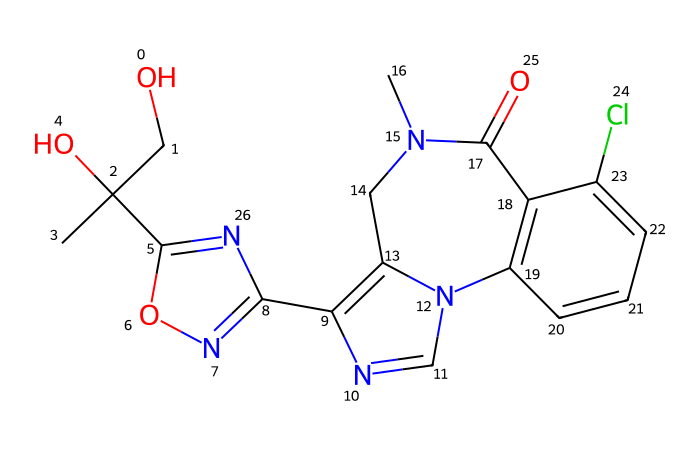


[2] 图级张量信息
节点数 num_nodes: 27
边数 num_edges（注意：PyG 中通常是有向边数）: 60
节点特征矩阵 x 的形状: (27, 9)
边索引 edge_index 的形状: (2, 60)
边特征矩阵 edge_attr 的形状: (60, 3)

[3] 节点特征解码表


,原子编号,原子符号,原始节点特征,原子序数,手性,度,形式电荷,氢原子数,自由基电子数,杂化方式,是否芳香,是否在环中
0,0,O,"[8, 0, 2, 5, 1, 0, 4, 0, 0]",8,CHI_UNSPECIFIED,2,0,1,0,SP3,False,False
1,1,C,"[6, 0, 4, 5, 2, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,2,0,SP3,False,False
2,2,C,"[6, 0, 4, 5, 0, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,0,0,SP3,False,False
3,3,C,"[6, 0, 4, 5, 3, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,3,0,SP3,False,False
4,4,O,"[8, 0, 2, 5, 1, 0, 4, 0, 0]",8,CHI_UNSPECIFIED,2,0,1,0,SP3,False,False
5,5,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True
6,6,O,"[8, 0, 2, 5, 0, 0, 3, 1, 1]",8,CHI_UNSPECIFIED,2,0,0,0,SP2,True,True
7,7,N,"[7, 0, 2, 5, 0, 0, 3, 1, 1]",7,CHI_UNSPECIFIED,2,0,0,0,SP2,True,True
8,8,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True
9,9,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True



[4] 边特征解码表（含连接关系）


,起点原子编号,起点原子符号,终点原子编号,终点原子符号,原始边特征,键类型,立体信息,是否共轭
0,0,O,1,C,"[1, 0, 0]",SINGLE,STEREONONE,False
1,1,C,2,C,"[1, 0, 0]",SINGLE,STEREONONE,False
2,2,C,3,C,"[1, 0, 0]",SINGLE,STEREONONE,False
3,2,C,4,O,"[1, 0, 0]",SINGLE,STEREONONE,False
4,2,C,5,C,"[1, 0, 0]",SINGLE,STEREONONE,False
5,5,C,6,O,"[12, 0, 1]",AROMATIC,STEREONONE,True
6,5,C,26,N,"[12, 0, 1]",AROMATIC,STEREONONE,True
7,6,O,7,N,"[12, 0, 1]",AROMATIC,STEREONONE,True
8,7,N,8,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
9,8,C,9,C,"[1, 0, 1]",SINGLE,STEREONONE,True



[5] 数据集中的原始 edge_index
tensor([[ 0,  1,  1,  2,  2,  2,  2,  3,  4,  5,  5,  5,  6,  6,  7,  7,  8,  8,
          8,  9,  9,  9, 10, 10, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 15, 15,
         15, 16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 20, 20, 21, 21, 22, 22, 23,
         23, 23, 24, 25, 26, 26],
        [ 1,  0,  2,  1,  3,  4,  5,  2,  2,  2,  6, 26,  5,  7,  6,  8,  7,  9,
         26,  8, 10, 13,  9, 11, 10, 12, 11, 13, 19,  9, 12, 14, 13, 15, 14, 16,
         17, 15, 15, 18, 25, 17, 19, 23, 12, 18, 20, 19, 21, 20, 22, 21, 23, 18,
         22, 24, 23, 17,  5,  8]])

[6] 数据集中的原始 edge_attr
tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [ 1,  0,  1],
  

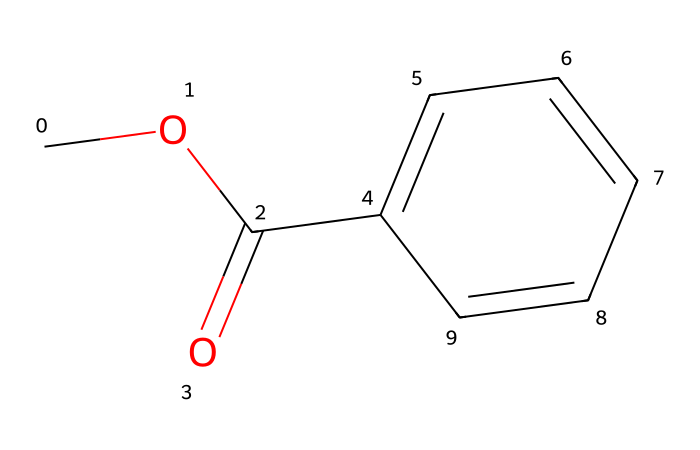


[2] 图级张量信息
节点数 num_nodes: 10
边数 num_edges（注意：PyG 中通常是有向边数）: 20
节点特征矩阵 x 的形状: (10, 9)
边索引 edge_index 的形状: (2, 20)
边特征矩阵 edge_attr 的形状: (20, 3)

[3] 节点特征解码表


,原子编号,原子符号,原始节点特征,原子序数,手性,度,形式电荷,氢原子数,自由基电子数,杂化方式,是否芳香,是否在环中
0,0,C,"[6, 0, 4, 5, 3, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,3,0,SP3,False,False
1,1,O,"[8, 0, 2, 5, 0, 0, 3, 0, 0]",8,CHI_UNSPECIFIED,2,0,0,0,SP2,False,False
2,2,C,"[6, 0, 3, 5, 0, 0, 3, 0, 0]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,False,False
3,3,O,"[8, 0, 1, 5, 0, 0, 3, 0, 0]",8,CHI_UNSPECIFIED,1,0,0,0,SP2,False,False
4,4,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True
5,5,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
6,6,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
7,7,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
8,8,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
9,9,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True



[4] 边特征解码表（含连接关系）


,起点原子编号,起点原子符号,终点原子编号,终点原子符号,原始边特征,键类型,立体信息,是否共轭
0,0,C,1,O,"[1, 0, 0]",SINGLE,STEREONONE,False
1,1,O,2,C,"[1, 0, 1]",SINGLE,STEREONONE,True
2,2,C,3,O,"[2, 0, 1]",DOUBLE,STEREONONE,True
3,2,C,4,C,"[1, 0, 1]",SINGLE,STEREONONE,True
4,4,C,5,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
5,4,C,9,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
6,5,C,6,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
7,6,C,7,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
8,7,C,8,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
9,8,C,9,C,"[12, 0, 1]",AROMATIC,STEREONONE,True



[5] 数据集中的原始 edge_index
tensor([[0, 1, 1, 2, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9],
        [1, 0, 2, 1, 3, 4, 2, 2, 5, 9, 4, 6, 5, 7, 6, 8, 7, 9, 4, 8]])

[6] 数据集中的原始 edge_attr
tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  1],
        [ 1,  0,  1],
        [ 2,  0,  1],
        [ 1,  0,  1],
        [ 2,  0,  1],
        [ 1,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1]])


In [3]:
# =========================================================
# 示例：查看一个 BBBP 分子
# =========================================================
show_molecule_data(ds_cls, cls_name, idx=10, unique_undirected=True)


# =========================================================
# 示例：查看一个 ESOL 分子
# =========================================================
show_molecule_data(ds_reg, reg_name, idx=726, unique_undirected=True)

### （4） 通用代码：GIN 模型（分类/回归）+  训练/评估

In [4]:
def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    将数据集按 train / val / test 划分
    默认比例：8 : 1 : 1
    """
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )
    return train_set, val_set, test_set


class MLP(nn.Module):
    """两层感知机：用于分类头或回归头"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),   # 线性映射到隐藏空间
            nn.ReLU(),                       # 非线性激活
            nn.Dropout(dropout),             # dropout 正则化
            nn.Linear(hidden_dim, out_dim),  # 输出层
        )

    def forward(self, x):
        return self.net(x)


class GINBackbone(nn.Module):
    """GIN 主干网络：输入图，输出图级 embedding"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()         # 存放多层 GINConv
        self.bns = nn.ModuleList()           # 存放每层 BatchNorm

        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),  # 第1层输入维度为 in_dim，其余层为 hidden_dim
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))          # GINConv：邻居聚合 + MLP 更新
            self.bns.append(nn.BatchNorm1d(hidden_dim))

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)                  # 节点消息传递
            x = bn(x)                                # 批标准化
            x = F.relu(x)                            # 非线性激活
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)               # 节点表示平均池化为图表示
        return g


class GINClassifier(nn.Module):
    """GIN 二分类模型：输出 2 维 logits"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 图神经网络主干
        self.head = MLP(hidden_dim, hidden_dim, 2, dropout)              # 分类头

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 图级 embedding
        return self.head(g)                                # logits [B, 2]


class GINRegressor(nn.Module):
    """GIN 回归模型：输出 1 个连续值"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 图神经网络主干
        self.head = MLP(hidden_dim, hidden_dim, 1, dropout)              # 回归头

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 图级 embedding
        return self.head(g).view(-1)                       # [B, 1] -> [B]


class GINMaskRegressor(nn.Module):
    """支持 pooling-mask 的回归模型：拆分为节点编码和图读出两步"""
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.x_proj = nn.Linear(in_dim, hidden_dim)  # 输入特征先映射到 hidden_dim

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp, train_eps=True))  # train_eps=True：epsilon 参数可学习
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),   # 回归输出
        )

    def encode_nodes(self, data):
        """节点编码阶段：输出每个节点的 embedding"""
        x = data.x.float()
        h = self.x_proj(x)

        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, data.edge_index)               # 节点消息传递
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        return h                                      # [N, hidden_dim]

    def readout(self, h, batch, node_keep_mask=None):
        """图读出阶段：支持在 pooling 时屏蔽部分节点"""
        if node_keep_mask is not None:
            h = h * node_keep_mask.view(-1, 1).to(h.dtype)  # 被屏蔽节点贡献置零

        g = global_add_pool(h, batch)                 # 节点表示求和为图表示
        out = self.head(g).view(-1)                   # 图级回归输出
        return out

    def forward(self, data, node_keep_mask=None):
        if not hasattr(data, "batch") or data.batch is None:
            data.batch = torch.zeros(
                data.num_nodes,
                dtype=torch.long,
                device=data.x.device
            )                                         # 单图时手动补 batch

        h = self.encode_nodes(data)                   # 节点编码
        out = self.readout(h, data.batch, node_keep_mask=node_keep_mask)  # 图读出
        return out


@torch.no_grad()
def eval_classification(model, loader, device):
    """分类评估：返回 accuracy"""
    model.eval()
    correct, total = 0, 0

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)                         # 分类 logits
        pred = logits.argmax(dim=-1)                  # 预测类别
        y = batch.y.view(-1).long()                   # 真实标签
        correct += int((pred == y).sum())
        total += y.numel()

    return correct / max(total, 1)


@torch.no_grad()
def eval_regression(model, loader, device):
    """回归评估：返回 RMSE 和 MAE"""
    model.eval()
    ys, ps = [], []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)                           # 预测值
        y = batch.y.view(-1).float()                  # 真实值
        ys.append(y.detach().cpu())
        ps.append(pred.detach().cpu())

    y = torch.cat(ys)
    p = torch.cat(ps)

    rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()   # 均方根误差
    mae = torch.mean(torch.abs(p - y)).item()            # 平均绝对误差
    return rmse, mae


def train_one_epoch_classification(model, loader, opt, device):
    """分类任务训练一个 epoch：返回平均交叉熵损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)                         # 前向传播
        y = batch.y.view(-1).long()                  # 真实标签
        loss = F.cross_entropy(logits, y)            # 交叉熵损失

        opt.zero_grad()
        loss.backward()                              # 反向传播
        opt.step()

        total_loss += loss.detach().item() * y.size(0)        # 按样本数累计损失

    return total_loss / max(len(loader.dataset), 1)


def train_one_epoch_regression(model, loader, opt, device):
    """回归任务训练一个 epoch：返回平均 MSE 损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)                          # 前向传播
        y = batch.y.view(-1).float()                 # 真实值
        loss = F.mse_loss(pred, y)                   # 均方误差损失

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.detach().item() * y.size(0)        # 按样本数累计损失

    return total_loss / max(len(loader.dataset), 1)
print("训练代码载入完成！")

训练代码载入完成！


### （5) BBBP 分类任务

In [5]:
# =========================
# 0. 超参数设置区域（可修不同超参数，探究超参数对结果的影响）
# =========================
HP = {
    "seed": 42,                  # 随机种子
    "batch_size_train": 64,      # 训练集 batch size
    "batch_size_eval": 256,      # 验证/测试 batch size
    "hidden_dim": 128,           # 隐藏层维度
    "num_layers": 4,             # GINConv 层数
    "dropout": 0.2,              # dropout 概率
    "lr": 1e-3,                  # 学习率
    "weight_decay": 1e-5,        # L2 正则
    "epochs": 100,               # 训练轮数
    "model_dir": "saved_models"  # 模型保存目录
}

# =========================
# 1. 打印当前超参数
# =========================
param_name_map = {
    "seed": "随机种子",
    "batch_size_train": "训练集批大小",
    "batch_size_eval": "验证/测试批大小",
    "hidden_dim": "隐藏层维度",
    "num_layers": "网络层数",
    "dropout": "Dropout 概率",
    "lr": "学习率",
    "weight_decay": "权重衰减",
    "epochs": "训练轮数",
    "model_dir": "模型保存目录"
}

print("当前实验超参数：")
for k, v in HP.items():
    print(f"{param_name_map.get(k, k)}: {v}")


# =========================
# 2. 工具函数
# =========================
def make_model_name(task_name="gin_cls", hp=None):
    """
    根据超参数自动生成模型文件名，便于比较不同实验结果
    """
    name = (
        f"{task_name}"
        f"_seed{hp['seed']}"
        f"_bs{hp['batch_size_train']}"
        f"_hd{hp['hidden_dim']}"
        f"_L{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_lr{hp['lr']}"
        f"_wd{hp['weight_decay']}"
        f"_ep{hp['epochs']}"
        f".pt"
    )
    return name


def build_subset_with_ids(subset):
    """
    将 Subset 转成新的样本列表，并补充：
    - dataset_id：在原始完整数据集中的编号
    - subset_id ：在当前子集中的编号

    便于后续保存预测结果并回查原始分子。
    """
    if hasattr(subset, "indices"):
        base_dataset = subset.dataset
        indices = list(subset.indices)
    else:
        base_dataset = subset
        indices = list(range(len(subset)))

    new_data_list = []
    for subset_id, dataset_id in enumerate(indices):
        data = copy.deepcopy(base_dataset[dataset_id])
        data.dataset_id = torch.tensor([dataset_id], dtype=torch.long)
        data.subset_id = torch.tensor([subset_id], dtype=torch.long)
        new_data_list.append(data)

    return new_data_list


@torch.no_grad()
def eval_classification_with_details(model, loader, device, full_dataset=None):
    """
    评估分类模型，并保留每个样本的详细预测结果。

    返回：
    - acc
    - pred_df：DataFrame，包含每个样本的详细预测信息
    """
    model.eval()
    rows = []

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)                    # [B, C]
        probs = torch.softmax(logits, dim=-1)   # [B, C]
        preds = logits.argmax(dim=-1)           # [B]
        y = batch.y.view(-1).long()             # [B]

        probs_np = probs.detach().cpu().numpy()
        preds_np = preds.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        dataset_ids = batch.dataset_id.view(-1).detach().cpu().numpy()
        subset_ids = batch.subset_id.view(-1).detach().cpu().numpy()

        num_classes = probs_np.shape[1]

        for i in range(len(y_np)):
            row = {
                "dataset_id": int(dataset_ids[i]),             # 原始完整数据集中的编号
                "true_label": int(y_np[i]),                   # 真实类别
                "pred_label": int(preds_np[i]),               # 预测类别
                "correct": int(preds_np[i] == y_np[i]),       # 是否预测正确
            }

            # 如果是二分类，额外补一个正类概率，便于后续分析
            if num_classes == 2:
                row["pred_prob_pos"] = float(probs_np[i, 1])

            # 如果原始数据集中带有 smiles 字段，就顺手补上
            if full_dataset is not None and hasattr(full_dataset[int(dataset_ids[i])], "smiles"):
                row["smiles"] = full_dataset[int(dataset_ids[i])].smiles

            rows.append(row)

    pred_df = pd.DataFrame(rows)
    acc = pred_df["correct"].mean()

    return acc, pred_df


# =========================
# 3. 数据集划分与加载
# =========================
train_set_raw, val_set_raw, test_set_raw = split_dataset(ds_cls, seed=HP["seed"])  # 按固定随机种子划分

# 训练集直接使用原始子集即可
train_loader = DataLoader(
    train_set_raw,
    batch_size=HP["batch_size_train"],
    shuffle=True
)

# 验证集、测试集补充 dataset_id / subset_id，便于保存预测结果
val_set = build_subset_with_ids(val_set_raw)
test_set = build_subset_with_ids(test_set_raw)

val_loader = DataLoader(
    val_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)
test_loader = DataLoader(
    test_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)


# =========================
# 4. 模型构建
# =========================
model_cls = GINClassifier(
    in_dim=ds_cls.num_features,         # 节点输入特征维度
    hidden_dim=HP["hidden_dim"],        # 隐藏层维度
    num_layers=HP["num_layers"],        # GINConv 层数
    dropout=HP["dropout"]               # dropout 概率
).to(device)


# =========================
# 5. 优化器设置
# =========================
opt = torch.optim.Adam(
    model_cls.parameters(),
    lr=HP["lr"],
    weight_decay=HP["weight_decay"]
)


# =========================
# 6. 训练过程
# =========================
best_val = 0.0
best_state = None

print("\n开始训练分类模型...")
train_start_time = time.time()   # 记录总训练开始时间

for epoch in range(1, HP["epochs"] + 1):
    epoch_start_time = time.time()   # 记录当前 epoch 开始时间

    loss = train_one_epoch_classification(
        model_cls, train_loader, opt, device
    )

    val_acc = eval_classification(
        model_cls, val_loader, device
    )

    # 若当前验证集性能更好，则保存最优参数
    if val_acc > best_val:
        best_val = val_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model_cls.state_dict().items()
        }

    epoch_time = time.time() - epoch_start_time         # 当前 epoch 用时
    total_time = time.time() - train_start_time         # 累计训练用时

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"第 {epoch:03d} 轮 | "
            f"训练损失 = {loss:.4f} | "
            f"验证集准确率 = {val_acc:.4f} | "
            f"本轮耗时 = {epoch_time:.2f} 秒 | "
            f"累计耗时 = {total_time:.2f} 秒"
        )


# =========================
# 7. 恢复最佳模型
# =========================
if best_state is not None:
    model_cls.load_state_dict(best_state)

total_train_time = time.time() - train_start_time
print(f"\n训练完成，总耗时：{total_train_time:.2f} 秒")


# =========================
# 8. 测试集评估，并保留预测结果
# =========================
test_acc, test_pred_df = eval_classification_with_details(
    model_cls,
    test_loader,
    device,
    full_dataset=ds_cls
)

print(f"最佳验证集准确率 = {best_val:.4f}")
print(f"测试集准确率     = {test_acc:.4f}")

print("\n测试集部分预测结果（前 10 条）：")
print(test_pred_df.head(10).to_string(index=False))


# =========================
# 9. 可选：也保留验证集预测结果
# =========================
val_acc_best, val_pred_df = eval_classification_with_details(
    model_cls,
    val_loader,
    device,
    full_dataset=ds_cls
)

print("\n验证集部分预测结果（前 5 条）：")
print(val_pred_df.head(5).to_string(index=False))


# =========================
# 10. 保存模型（文件名包含超参数）
# =========================
Path(HP["model_dir"]).mkdir(parents=True, exist_ok=True)

save_name = make_model_name(task_name="gin_cls", hp=HP)
save_path = os.path.join(HP["model_dir"], save_name)

torch.save({
    "model_state_dict": model_cls.state_dict(),  # 最优模型参数
}, save_path)

print(f"\n模型已保存到：{save_path}")


# =========================
# 11. 额外保存预测结果，便于后续分析
# =========================
test_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_测试集预测结果.csv")
)
val_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_验证集预测结果.csv")
)

test_pred_df.to_csv(test_pred_path, index=False, encoding="utf-8-sig")
val_pred_df.to_csv(val_pred_path, index=False, encoding="utf-8-sig")

print(f"测试集预测结果已保存到：{test_pred_path}")
print(f"验证集预测结果已保存到：{val_pred_path}")

当前实验超参数：
随机种子: 42
训练集批大小: 64
验证/测试批大小: 256
隐藏层维度: 128
网络层数: 4
Dropout 概率: 0.2
学习率: 0.001
权重衰减: 1e-05
训练轮数: 100
模型保存目录: saved_models

开始训练分类模型...
第 001 轮 | 训练损失 = 0.4915 | 验证集准确率 = 0.7340 | 本轮耗时 = 0.71 秒 | 累计耗时 = 0.71 秒
第 010 轮 | 训练损失 = 0.3505 | 验证集准确率 = 0.8424 | 本轮耗时 = 0.21 秒 | 累计耗时 = 2.81 秒
第 020 轮 | 训练损失 = 0.2934 | 验证集准确率 = 0.6158 | 本轮耗时 = 0.24 秒 | 累计耗时 = 5.02 秒
第 030 轮 | 训练损失 = 0.2636 | 验证集准确率 = 0.8030 | 本轮耗时 = 0.23 秒 | 累计耗时 = 7.48 秒
第 040 轮 | 训练损失 = 0.2477 | 验证集准确率 = 0.8473 | 本轮耗时 = 0.23 秒 | 累计耗时 = 9.82 秒
第 050 轮 | 训练损失 = 0.2369 | 验证集准确率 = 0.8374 | 本轮耗时 = 0.19 秒 | 累计耗时 = 11.82 秒
第 060 轮 | 训练损失 = 0.2251 | 验证集准确率 = 0.8325 | 本轮耗时 = 0.25 秒 | 累计耗时 = 13.92 秒
第 070 轮 | 训练损失 = 0.2029 | 验证集准确率 = 0.8276 | 本轮耗时 = 0.21 秒 | 累计耗时 = 16.12 秒
第 080 轮 | 训练损失 = 0.1669 | 验证集准确率 = 0.8719 | 本轮耗时 = 0.26 秒 | 累计耗时 = 18.38 秒
第 090 轮 | 训练损失 = 0.1616 | 验证集准确率 = 0.8670 | 本轮耗时 = 0.24 秒 | 累计耗时 = 20.67 秒
第 100 轮 | 训练损失 = 0.1521 | 验证集准确率 = 0.8128 | 本轮耗时 = 0.25 秒 | 累计耗时 = 23.23 秒

训练完成，总耗时：23.23 秒
最佳验证集准确率 = 0.8818

### （6）ESOL 回归训练

In [6]:
# =========================
# 0. 超参数设置区域（主要修改这里）
# =========================
HP = {
    "seed": 42,                  # 随机种子
    "batch_size_train": 64,      # 训练集 batch size
    "batch_size_eval": 256,      # 验证/测试 batch size
    "hidden_dim": 128,           # 隐藏层维度
    "num_layers": 4,             # GINConv 层数
    "dropout": 0.2,              # dropout 概率
    "lr": 1e-3,                  # 学习率
    "weight_decay": 1e-5,        # L2 正则
    "epochs": 100,               # 训练轮数
    "model_dir": "saved_models", # 模型保存目录
    "task_name": "gin_reg"       # 任务名称
}

# =========================
# 1. 打印当前超参数
# =========================
param_name_map = {
    "seed": "随机种子",
    "batch_size_train": "训练集批大小",
    "batch_size_eval": "验证/测试批大小",
    "hidden_dim": "隐藏层维度",
    "num_layers": "网络层数",
    "dropout": "Dropout 概率",
    "lr": "学习率",
    "weight_decay": "权重衰减",
    "epochs": "训练轮数",
    "model_dir": "模型保存目录",
    "task_name": "任务名称"
}

print("当前实验超参数：")
for k, v in HP.items():
    print(f"{param_name_map.get(k, k)}: {v}")


# =========================
# 2. 数据集划分函数
# =========================
def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    将数据集划分为训练集 / 验证集 / 测试集
    """
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )
    return train_set, val_set, test_set


# =========================
# 3. 生成模型保存文件名
# =========================
def make_model_name(task_name="gin_reg", hp=None):
    name = (
        f"{task_name}"
        f"_seed{hp['seed']}"
        f"_bs{hp['batch_size_train']}"
        f"_hd{hp['hidden_dim']}"
        f"_L{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_lr{hp['lr']}"
        f"_wd{hp['weight_decay']}"
        f"_ep{hp['epochs']}"
        f".pt"
    )
    return name


# =========================
# 4. 给验证/测试子集补充索引信息
# =========================
def build_subset_with_ids(subset):
    """
    将 Subset 转成一个新的样本列表，并为每个样本补充：
    - dataset_id：在原始完整数据集中的编号
    - subset_id ：在当前子集中的编号

    这样在保存预测结果时，便于回查原始分子。
    """
    if hasattr(subset, "indices"):
        base_dataset = subset.dataset
        indices = list(subset.indices)
    else:
        base_dataset = subset
        indices = list(range(len(subset)))

    new_data_list = []
    for subset_id, dataset_id in enumerate(indices):
        data = copy.deepcopy(base_dataset[dataset_id])
        data.dataset_id = torch.tensor([dataset_id], dtype=torch.long)
        data.subset_id = torch.tensor([subset_id], dtype=torch.long)
        new_data_list.append(data)

    return new_data_list


# =========================
# 5. 训练一个 epoch
# =========================
def train_one_epoch_regression(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        loss = torch.nn.functional.mse_loss(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * y.size(0)
        total_samples += y.size(0)

    return total_loss / total_samples


# =========================
# 6. 回归评估：仅返回指标
# =========================
@torch.no_grad()
def eval_regression(model, loader, device):
    model.eval()
    preds_all = []
    trues_all = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        preds_all.append(pred.detach().cpu())
        trues_all.append(y.detach().cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    trues_all = torch.cat(trues_all, dim=0).numpy()

    rmse = np.sqrt(((preds_all - trues_all) ** 2).mean())
    mae = np.abs(preds_all - trues_all).mean()
    return rmse, mae


# =========================
# 7. 回归评估：返回详细预测结果
# =========================
@torch.no_grad()
def eval_regression_with_details(model, loader, device, full_dataset=None):
    """
    在评估时同时保留每个样本的预测结果，便于后续分析。

    返回：
    - rmse
    - mae
    - pred_df：DataFrame，包含每个样本的详细预测信息
    """
    model.eval()
    rows = []

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        pred_np = pred.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        dataset_ids = batch.dataset_id.view(-1).detach().cpu().numpy()
        subset_ids = batch.subset_id.view(-1).detach().cpu().numpy()

        for i in range(len(y_np)):
            row = {
                "dataset_id": int(dataset_ids[i]),     # 原始完整数据集中的编号
                "true_value": float(y_np[i]),          # 真实值
                "pred_value": float(pred_np[i]),       # 预测值
                "abs_error": float(abs(pred_np[i] - y_np[i]))  # 绝对误差
            }

            # 如果原始数据集中带有 smiles 字段，就顺手补上
            if full_dataset is not None and hasattr(full_dataset[int(dataset_ids[i])], "smiles"):
                row["smiles"] = full_dataset[int(dataset_ids[i])].smiles

            rows.append(row)

    pred_df = pd.DataFrame(rows)

    rmse = np.sqrt(((pred_df["pred_value"] - pred_df["true_value"]) ** 2).mean())
    mae = np.abs(pred_df["pred_value"] - pred_df["true_value"]).mean()

    return rmse, mae, pred_df


# =========================
# 8. 数据集划分与加载
# =========================
train_set_raw, val_set_raw, test_set_raw = split_dataset(ds_reg, seed=HP["seed"])

# 训练集直接使用原始子集即可
train_loader = DataLoader(
    train_set_raw,
    batch_size=HP["batch_size_train"],
    shuffle=True
)

# 验证集、测试集为了保留样本编号，额外补充 dataset_id / subset_id
val_set = build_subset_with_ids(val_set_raw)
test_set = build_subset_with_ids(test_set_raw)

val_loader = DataLoader(
    val_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)
test_loader = DataLoader(
    test_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)


# =========================
# 9. 模型构建
# =========================
model_reg = GINRegressor(
    in_dim=ds_reg.num_features,
    hidden_dim=HP["hidden_dim"],
    num_layers=HP["num_layers"],
    dropout=HP["dropout"]
).to(device)


# =========================
# 10. 优化器设置
# =========================
opt = torch.optim.Adam(
    model_reg.parameters(),
    lr=HP["lr"],
    weight_decay=HP["weight_decay"]
)


# =========================
# 11. 训练过程
# =========================
best_val = float("inf")   # 回归任务中，RMSE 越小越好
best_state = None

print("\n开始训练回归模型...")
train_start_time = time.time()

for epoch in range(1, HP["epochs"] + 1):
    epoch_start_time = time.time()

    loss = train_one_epoch_regression(
        model_reg, train_loader, opt, device
    )

    val_rmse, val_mae = eval_regression(
        model_reg, val_loader, device
    )

    # 保存验证集上表现最好的模型
    if val_rmse < best_val:
        best_val = val_rmse
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model_reg.state_dict().items()
        }

    epoch_time = time.time() - epoch_start_time
    total_time = time.time() - train_start_time

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"第 {epoch:03d} 轮 | "
            f"训练损失 = {loss:.4f} | "
            f"验证集 RMSE = {val_rmse:.4f} | "
            f"验证集 MAE = {val_mae:.4f} | "
            f"本轮耗时 = {epoch_time:.2f} 秒 | "
            f"累计耗时 = {total_time:.2f} 秒"
        )


# =========================
# 12. 恢复最佳模型
# =========================
if best_state is not None:
    model_reg.load_state_dict(best_state)

total_train_time = time.time() - train_start_time
print(f"\n训练完成，总耗时：{total_train_time:.2f} 秒")


# =========================
# 13. 测试集评估，并保留预测结果
# =========================
test_rmse, test_mae, test_pred_df = eval_regression_with_details(
    model_reg,
    test_loader,
    device,
    full_dataset=ds_reg
)

print(f"最佳验证集 RMSE = {best_val:.4f}")
print(f"测试集 RMSE     = {test_rmse:.4f}")
print(f"测试集 MAE      = {test_mae:.4f}")

print("\n测试集部分预测结果（前 10 条）：")
print(test_pred_df.head(10).to_string(index=False))


# =========================
# 14. 可选：也保留验证集预测结果
# =========================
val_rmse_best, val_mae_best, val_pred_df = eval_regression_with_details(
    model_reg,
    val_loader,
    device,
    full_dataset=ds_reg
)

print("\n验证集部分预测结果（前 10 条）：")
print(val_pred_df.head(10).to_string(index=False))


# =========================
# 15. 保存最佳模型
# =========================
Path(HP["model_dir"]).mkdir(parents=True, exist_ok=True)

save_name = make_model_name(task_name=HP["task_name"], hp=HP)
save_path = os.path.join(HP["model_dir"], save_name)

torch.save({
    "model_state_dict": model_reg.state_dict(),  # 最优模型参数
}, save_path)

print(f"\n模型已保存到：{save_path}")


# =========================
# 16. 额外保存预测结果，便于后续分析
# =========================
test_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_测试集预测结果.csv")
)
val_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_验证集预测结果.csv")
)

test_pred_df.to_csv(test_pred_path, index=False, encoding="utf-8-sig")
val_pred_df.to_csv(val_pred_path, index=False, encoding="utf-8-sig")

print(f"测试集预测结果已保存到：{test_pred_path}")
print(f"验证集预测结果已保存到：{val_pred_path}")

当前实验超参数：
随机种子: 42
训练集批大小: 64
验证/测试批大小: 256
隐藏层维度: 128
网络层数: 4
Dropout 概率: 0.2
学习率: 0.001
权重衰减: 1e-05
训练轮数: 100
模型保存目录: saved_models
任务名称: gin_reg

开始训练回归模型...
第 001 轮 | 训练损失 = 6.9978 | 验证集 RMSE = 1.8281 | 验证集 MAE = 1.4648 | 本轮耗时 = 0.23 秒 | 累计耗时 = 0.23 秒
第 010 轮 | 训练损失 = 1.3804 | 验证集 RMSE = 1.0935 | 验证集 MAE = 0.8288 | 本轮耗时 = 0.12 秒 | 累计耗时 = 1.34 秒
第 020 轮 | 训练损失 = 0.9815 | 验证集 RMSE = 1.0918 | 验证集 MAE = 0.8510 | 本轮耗时 = 0.11 秒 | 累计耗时 = 2.51 秒
第 030 轮 | 训练损失 = 0.8739 | 验证集 RMSE = 2.9237 | 验证集 MAE = 2.3891 | 本轮耗时 = 0.11 秒 | 累计耗时 = 3.67 秒
第 040 轮 | 训练损失 = 0.8931 | 验证集 RMSE = 1.1952 | 验证集 MAE = 0.9131 | 本轮耗时 = 0.11 秒 | 累计耗时 = 4.80 秒
第 050 轮 | 训练损失 = 0.8181 | 验证集 RMSE = 1.3051 | 验证集 MAE = 0.9397 | 本轮耗时 = 0.11 秒 | 累计耗时 = 5.89 秒
第 060 轮 | 训练损失 = 0.8071 | 验证集 RMSE = 1.1722 | 验证集 MAE = 0.8977 | 本轮耗时 = 0.11 秒 | 累计耗时 = 7.02 秒
第 070 轮 | 训练损失 = 0.9826 | 验证集 RMSE = 1.4805 | 验证集 MAE = 1.1087 | 本轮耗时 = 0.12 秒 | 累计耗时 = 8.13 秒
第 080 轮 | 训练损失 = 0.7047 | 验证集 RMSE = 1.0588 | 验证集 MAE = 0.7740 | 本轮耗时 = 0.14 秒 | 

### （8）GIN 模型结构与超参数的探究题
探究：
1. GIN 的层数是不是越多越好？
请尝试改变 num_layers，例如 2 层、4 层、6 层，观察训练结果。比较不同层数下：<br>
训练速度是否变化<br>
验证集性能是否提升<br>
是否出现性能反而下降的情况 <br>
进一步思考：为什么层数增多后，模型不一定更好？
2. dropout 对训练过程有什么影响？
请尝试设置不同的 dropout，例如 0、0.2、0.5。观察：<br>
训练集损失下降速度是否变化 <br>
验证集表现是否更稳定 <br>
模型是否更容易过拟合 <br>
思考：为什么 dropout 太小和太大都可能不好？
3. 更深的模型为什么可能反而表现变差？
如果层数增加后模型效果下降，请思考可能原因：<br>
是过拟合了，还是节点表示变得过于相似了？<br>
对分子图来说，过多层数会不会导致原子之间的差异被“平均掉”？
5. hidden_dim 越大越好吗？
请尝试不同隐藏维度，例如 64、128、256。观察：<br>
模型训练时间是否增加 <br>
显存占用是否增加 <br>
模型性能是否一定提高 <br>
思考：更大的模型为什么不一定更适合当前数据集？